<a href="https://colab.research.google.com/github/hazra-kerubo/2019-and-2020---Analysis/blob/main/Hazra_Kerubo_2019_%26_2020_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Company XXX wants to know if switching the prepayment fee from a flat 500 KES to 10% of the farmer’s loan size improves repayment outcomes.
Baseline (normal system): Flat 500 KES prepayment by December.
Trial (2019 & 2020 in Chwele, Bungoma, Lugari): 10% of loan size as prepayment.

**Required **

1. Analyze repayment and drop‑out data from those districts in 2019 and 2020.
2. Decide whether to scale the 10% prepayment, keep the flat fee, or test another variation.
3. Write a 1–2 page memo with evidence and a recommendation.


Steps Undertaken
1. Imported 2019 and 2020 dataset
2. Data understanding
3. Data cleaning
4. Visualization
5. Comparison of trial vs non trial disticts
6. Final conclusion and recommendation

In [ ]:
# Import libraries
import pandas as pd

# Upload files
from google.colab import files
uploaded = files.upload()

# 3. Load the Excel files
df2019 = pd.read_excel("2019.xlsx", sheet_name="Sheet1", engine="openpyxl")
df2020 = pd.read_excel("2020.xlsx", sheet_name="Sheet1", engine="openpyxl")



Saving 2019.xlsx to 2019 (3).xlsx
Saving 2020.xlsx to 2020 (3).xlsx


In [ ]:
#  Preview the first few rows
print("2019 Data:")
print(df2019.head())





2019 Data:
       DistrictName  No of enrolled farmers  No of qualified clients  \
0           Bungoma                   12303                     9451   
1  Kakamega (South)                   12946                    11140   
2            Webuye                   15914                    11352   
3            Chwele                   10779                     7572   
4            Butere                   16150                    13513   

   No of farmers who repaid  No of farmers who defaulted  \
0                      9131                          320   
1                     11141                           -1   
2                     11321                           31   
3                      7571                            1   
4                     13351                          162   

   % of Farmer who qualified  % of Farmer who repaid  \
0                   0.768187                0.966141   
1                   0.860497                1.000090   
2                   0.71333

There is negative value in the column defaulted hence need for data cleaning and filling it with a numerical value

In [ ]:

# previewing 2020 data
print("\n2020 Data:")
print(df2020.head())



2020 Data:
           Year  RepaymentRate  DefaultRate  QualificationRate
Group                                                         
Non-Trial  2020       0.905449     0.094551           0.784205
Trial      2020       0.948788     0.051212           0.749912


In [ ]:
# Check basic info -- datatypes
print("\n2019 Info:")
print(df2019.info())



2019 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   DistrictName                 22 non-null     object 
 1   No of enrolled farmers       22 non-null     int64  
 2   No of qualified clients      22 non-null     int64  
 3   No of farmers who repaid     22 non-null     int64  
 4   No of farmers who defaulted  22 non-null     int64  
 5   % of Farmer who qualified    22 non-null     float64
 6   % of Farmer who repaid       22 non-null     float64
 7   % of farmers who defaulted   22 non-null     float64
 8   Revenue                      22 non-null     int64  
 9   Amount defaulted             22 non-null     float64
 10  Repayment percentage         22 non-null     float64
dtypes: float64(5), int64(5), object(1)
memory usage: 2.0+ KB
None


In [ ]:
#  Check basic info for 2020
print("\n2020 Info:")
print(df2020.info())


2020 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   DistrictName                 22 non-null     object 
 1   No of enrolled farmers       22 non-null     int64  
 2   No of qualified clients      22 non-null     int64  
 3   No of farmers who repaid     22 non-null     int64  
 4   No of farmers who defaulted  22 non-null     int64  
 5   % of Farmer who qualified    22 non-null     float64
 6   % of Farmer who repaid       22 non-null     float64
 7   % of farmers who defaulted   22 non-null     float64
 8   Revenue                      22 non-null     float64
 9   Amount defaulted             22 non-null     float64
 10  Repayment percentage         22 non-null     float64
dtypes: float64(6), int64(4), object(1)
memory usage: 2.0+ KB
None


Data **Cleaning**

In [ ]:

# Rename columns for easier handling
df2019 = df2019.rename(columns={
    "No of enrolled farmers":"Enrolled",
    "No of qualified clients":"Qualified",
    "No of farmers who repaid":"Repaid",
    "No of farmers who defaulted":"Defaulted",
    "Revenue":"Revenue",
    "Amount defaulted":"AmountDefaulted"
})

df2019


,DistrictName,Enrolled,Qualified,Repaid,Defaulted,% of Farmer who qualified,% of Farmer who repaid,% of farmers who defaulted,Revenue,AmountDefaulted,Repayment percentage
0,Bungoma,12303,9451,9131,320,0.768187,0.966141,0.033859,87247064,976709.8,0.011195
1,Kakamega (South),12946,11140,11141,-1,0.860497,1.000090,-0.000090,106084947,0.0,0.000000
2,Webuye,15914,11352,11321,31,0.713334,0.997269,0.002731,107753820,102320.0,0.000950
3,Chwele,10779,7572,7571,1,0.702477,0.999868,0.000132,75050421,1000.0,0.000013
4,Butere,16150,13513,13351,162,0.836718,0.988012,0.011988,137692303,586438.0,0.004259
5,Teso,15840,12538,12451,87,0.791540,0.993061,0.006939,130486933,314303.0,0.002409
6,Busia,14544,11981,11518,463,0.823776,0.961355,0.038645,125174335,1637690.0,0.013083
7,Lugari,17022,13730,13525,205,0.806603,0.985069,0.014931,173566072,828483.0,0.004773
8,Kakamega B (North),15921,12503,12491,12,0.785315,0.999040,0.000960,122188682,64127.0,0.000525
9,Sirisia,10302,8031,7929,102,0.779557,0.987299,0.012701,89497401,445286.0,0.004975


In [ ]:
df2020 = df2020.rename(columns={
    "No of enrolled farmers":"Enrolled",
    "No of qualified clients":"Qualified",
    "No of farmers who repaid":"Repaid",
    "No of farmers who defaulted":"Defaulted",
    "Revenue":"Revenue",
    "Amount defaulted":"AmountDefaulted"
})
df2020

,DistrictName,Enrolled,Qualified,Repaid,Defaulted,% of Farmer who qualified,% of Farmer who repaid,% of farmers who defaulted,Revenue,AmountDefaulted,Repayment percentage
0,Bungoma,12678,9686,8690,996,0.764001,0.897171,0.102829,8.618689e+07,3967686.00,0.046036
1,Kakamega (South),14362,12036,11939,97,0.838045,0.991941,0.008059,1.080850e+08,325060.00,0.003007
2,Webuye,15824,11617,10867,750,0.734138,0.935439,0.064561,1.047591e+08,2421266.50,0.023113
3,Chwele,10912,7167,7113,54,0.656800,0.992465,0.007535,6.328924e+07,182513.00,0.002884
4,Butere,15218,12963,12770,193,0.851820,0.985111,0.014889,1.266593e+08,695389.00,0.005490
5,Teso,18589,14538,14426,112,0.782075,0.992296,0.007704,1.408059e+08,484767.00,0.003443
6,Busia,15182,11897,10945,952,0.783625,0.919980,0.080020,1.139734e+08,4172865.00,0.036613
7,Lugari,18455,15298,14636,662,0.828935,0.956726,0.043274,1.869254e+08,2723943.00,0.014572
8,Kakamega B (North),15553,12366,12068,298,0.795088,0.975902,0.024098,1.213791e+08,1132674.00,0.009332
9,Sirisia,12174,9668,8600,1068,0.794151,0.889532,0.110468,1.097651e+08,4491044.00,0.040915


In [ ]:
#  Fix negative values in defaulted column
df2019['Defaulted'] = df2019['Defaulted'].clip(lower=0)




In [ ]:
#  Recalculate repayment and default rates
for df in [df2019, df2020]:
    df['RepaymentRate'] = df['Repaid'] / df['Qualified']
    df['DefaultRate'] = df['Defaulted'] / df['Qualified']
    df['QualificationRate'] = df['Qualified'] / df['Enrolled']





In [ ]:
#  printing repayment , default rates and qualification rates  -2019
print(df2019[['DistrictName','RepaymentRate','DefaultRate','QualificationRate']].head())



       DistrictName  RepaymentRate  DefaultRate  QualificationRate
0           Bungoma       0.966141     0.033859           0.768187
1  Kakamega (South)       1.000090     0.000000           0.860497
2            Webuye       0.997269     0.002731           0.713334
3            Chwele       0.999868     0.000132           0.702477
4            Butere       0.988012     0.011988           0.836718


In [ ]:
#  printing repayment , default rates and qualification rates  -2020
print(df2020[['DistrictName','RepaymentRate','DefaultRate','QualificationRate']].head())



       DistrictName  RepaymentRate  DefaultRate  QualificationRate
0           Bungoma       0.897171     0.102829           0.764001
1  Kakamega (South)       0.991941     0.008059           0.838045
2            Webuye       0.935439     0.064561           0.734138
3            Chwele       0.992465     0.007535           0.656800
4            Butere       0.985111     0.014889           0.851820


In [ ]:

# Add year labels
df2019['Year'] = 2019
df2020['Year'] = 2020




In [ ]:
# Combine datasets
df_all = pd.concat([df2019[['DistrictName','RepaymentRate','DefaultRate','QualificationRate','Year']],
                    df2020[['DistrictName','RepaymentRate','DefaultRate','QualificationRate','Year']]])

In [ ]:
# previwing combined dataset - 2019 & 2020
df_all

,DistrictName,RepaymentRate,DefaultRate,QualificationRate,Year
0,Bungoma,0.966141,0.033859,0.768187,2019
1,Kakamega (South),1.000090,0.000000,0.860497,2019
2,Webuye,0.997269,0.002731,0.713334,2019
3,Chwele,0.999868,0.000132,0.702477,2019
4,Butere,0.988012,0.011988,0.836718,2019
5,Teso,0.993061,0.006939,0.791540,2019
6,Busia,0.961355,0.038645,0.823776,2019
7,Lugari,0.985069,0.014931,0.806603,2019
8,Kakamega B (North),0.999040,0.000960,0.785315,2019
9,Sirisia,0.987299,0.012701,0.779557,2019


In [ ]:
# Define trial districts
trial_districts = ['Chwele','Bungoma','Lugari']





In [ ]:
trial_districts

['Chwele', 'Bungoma', 'Lugari']

In [ ]:
df_trials = df_all[df_all['DistrictName'].isin(trial_districts)]

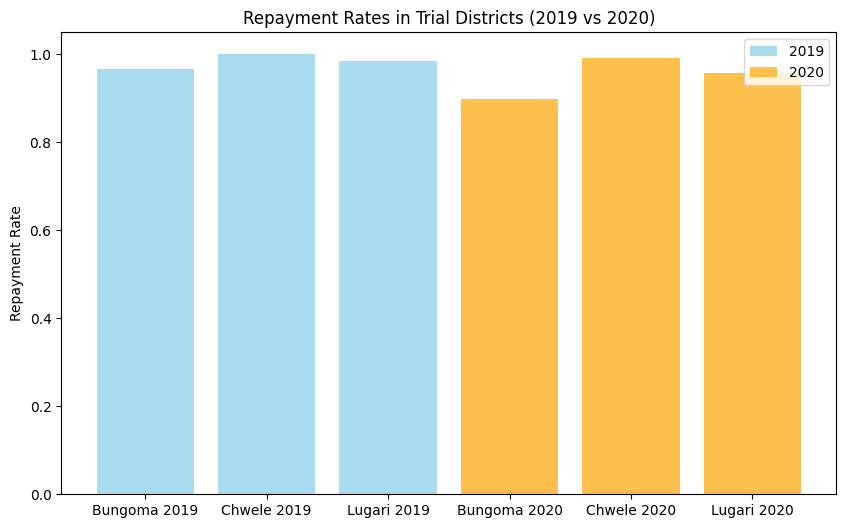

In [ ]:
# Plot repayment rates for trial districts
plt.figure(figsize=(10,6))
for year, color in zip([2019,2020], ['skyblue','orange']):
    subset = df_trials[df_trials['Year']==year]
    plt.bar(subset['DistrictName'] + " " + subset['Year'].astype(str),
            subset['RepaymentRate'], color=color, alpha=0.7, label=str(year))
plt.xticks(rotation=0)
plt.title("Repayment Rates in Trial Districts (2019 vs 2020)")
plt.ylabel("Repayment Rate")
plt.legend()
plt.show()

1. Bungoma

2019: ~96.6% repaid

2020: ~89.7% repaid

Drop of ~7 %

2. Chwele

2019: ~99.99% repaid (almost perfect)

2020: ~99.2% repaid

Slight decline, but still very strong repayment.

3. Lugari

2019: ~98.5% repaid

2020: ~95.7% repaid

Drop of 3%.

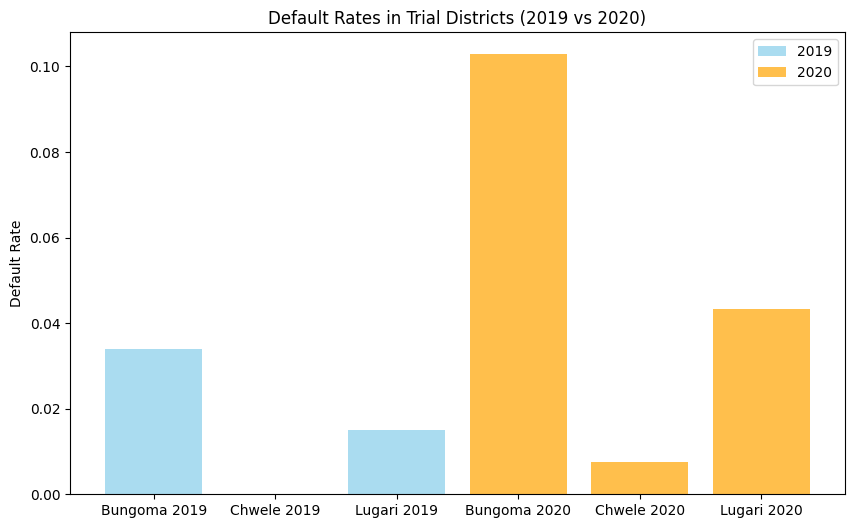

In [ ]:
# Plot default rates for trial districts
plt.figure(figsize=(10,6))
for year, color in zip([2019,2020], ['skyblue','orange']):
    subset = df_trials[df_trials['Year']==year]
    plt.bar(subset['DistrictName'] + " " + subset['Year'].astype(str),
            subset['DefaultRate'], color=color, alpha=0.7, label=str(year))
plt.xticks(rotation=0)
plt.title("Default Rates in Trial Districts (2019 vs 2020)")
plt.ylabel("Default Rate")
plt.legend()
plt.show()

1. Bungoma

2019: ~3.4% defaulted

2020: ~10.3% defaulted

Defaults tripled.

2. Chwele

2019: ~0.01% defaulted

2020: ~0.75% defaulted

Still low, but higher than before.

3. Lugari

2019: ~1.5% defaulted

2020: ~4.3% defaulted

Defaults increased.

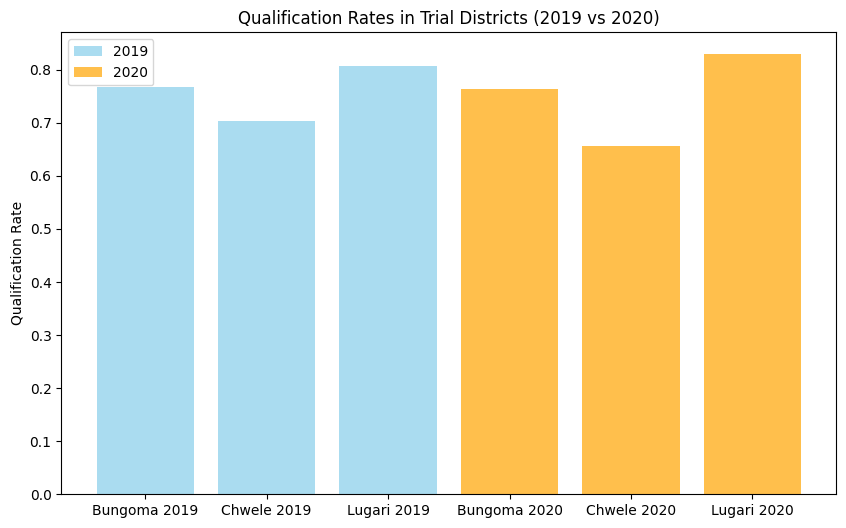

In [ ]:
# Plot qualification rates for trial districts
plt.figure(figsize=(10,6))
for year, color in zip([2019,2020], ['skyblue','orange']):
    subset = df_trials[df_trials['Year']==year]
    plt.bar(subset['DistrictName'] + " " + subset['Year'].astype(str),
            subset['QualificationRate'], color=color, alpha=0.7, label=str(year))
plt.xticks(rotation=0)
plt.title("Qualification Rates in Trial Districts (2019 vs 2020)")
plt.ylabel("Qualification Rate")
plt.legend()
plt.show()

Drop‑Outs (*Qualification Rate = Qualified ÷ Enrolled*)
1. Bungoma

2019: ~76.8% qualified

2020: ~76.4% qualified

Stable.

2. Chwele

2019: ~70.2% qualified

2020: ~65.7% qualified

Slight decline.

3.Lugari

2019: ~80.7% qualified

2020: ~82.9% qualified

Slight improvement.

**Observations**

1. Repayment weakened in Bungoma and Lugari.

2. Defaults increased significantly, especially in Bungoma.(trippled from 3.4% to around 10%)

3. Qualification rates stayed stable, meaning farmers could still join, but repayment discipline declined.

**Further Analysis** - Trial vs Non Trial District Comparison


In [ ]:

# Define trial districts and non trial districts
#trial_districts = ['Chwele','Bungoma','Lugari'] -already defined above
df_all['Group'] = df_all['DistrictName'].apply(lambda x: 'Trial' if any(t in x for t in trial_districts) else 'Non-Trial')

In [ ]:
# Compute averages by group and year (numeric columns only)
avg_rates = df_all.groupby(['Year','Group'])[['RepaymentRate','DefaultRate','QualificationRate']].mean().reset_index()
print("Average Rates by Group and Year:")
print(avg_rates)

Average Rates by Group and Year:
   Year      Group  RepaymentRate  DefaultRate  QualificationRate
0  2019  Non-Trial       0.952149     0.047856           0.794623
1  2019      Trial       0.983693     0.016307           0.759089
2  2020  Non-Trial       0.905449     0.094551           0.784205
3  2020      Trial       0.948788     0.051212           0.749912


In [ ]:

# Separate trial and non-trial for each year
df2019 = avg_rates[avg_rates['Year'] == 2019].set_index('Group')
df2020 = avg_rates[avg_rates['Year'] == 2020].set_index('Group')

# Compute year-over-year changes
yoy_changes = df2020[['RepaymentRate','DefaultRate','QualificationRate']] - df2019[['RepaymentRate','DefaultRate','QualificationRate']]

# Rename columns for clarity
yoy_changes = yoy_changes.rename(columns={
    'RepaymentRate':'RepaymentRate_YoY_Change',
    'DefaultRate':'DefaultRate_YoY_Change',
    'QualificationRate':'QualificationRate_YoY_Change'
})

print("\nYear-over-Year Changes (2020 - 2019):")
print(yoy_changes)








Year-over-Year Changes (2020 - 2019):
           RepaymentRate_YoY_Change  DefaultRate_YoY_Change  \
Group                                                         
Non-Trial                 -0.046700                0.046696   
Trial                     -0.034905                0.034905   

           QualificationRate_YoY_Change  
Group                                    
Non-Trial                     -0.010418  
Trial                         -0.009177  


Trial districts had smaller declines in repayment and smaller increases in defaults compared to non‑trial districts, showing stronger performance under the 10% fee.  
Both groups saw slight drops in qualification rates, but enrollment remained stable overall, meaning the fee did not discourage participation

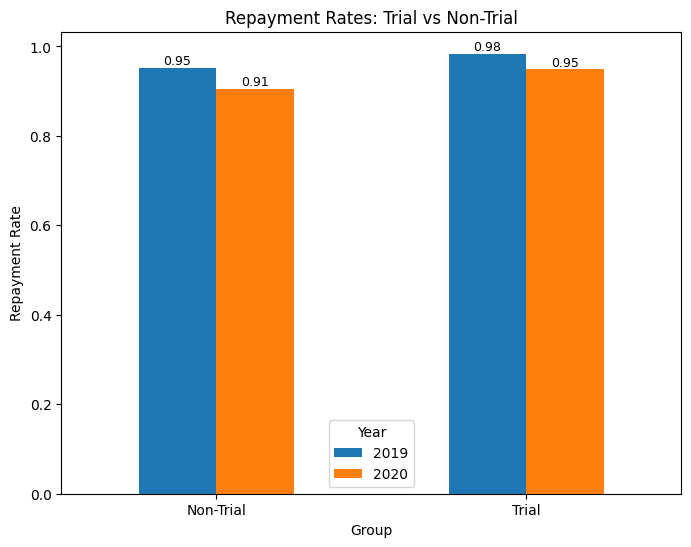

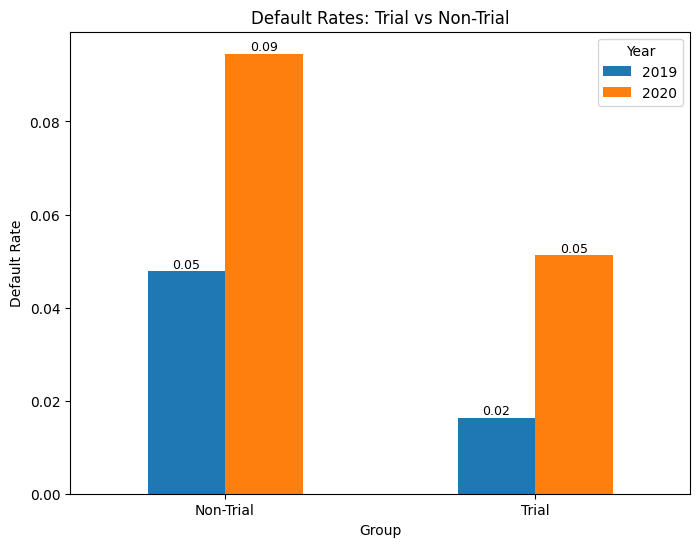

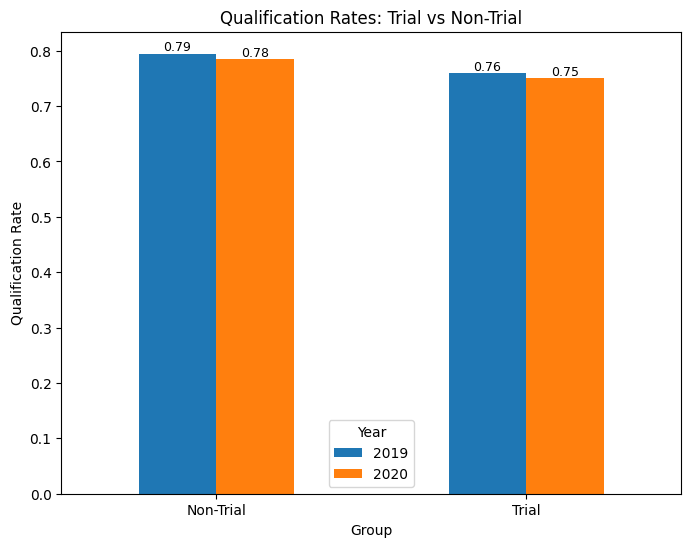

In [ ]:
# Visualizations
plot_grouped_bar(avg_rates, 'RepaymentRate', 'Repayment Rates: Trial vs Non-Trial', 'Repayment Rate')
plot_grouped_bar(avg_rates, 'DefaultRate', 'Default Rates: Trial vs Non-Trial', 'Default Rate')
plot_grouped_bar(avg_rates, 'QualificationRate', 'Qualification Rates: Trial vs Non-Trial', 'Qualification Rate')

**Observations**

Repayment Rates

*Trial districts*

2019: ~98%

2020: ~95%

*Non‑trial districts*

2019: ~95%

2020: ~91%

Trial districts maintained higher repayment rates, though both groups declined in 2020.

**Default Rates**

Trial districts -

2019: ~1.7%

2020: ~5.1%

Non‑trial districts -

2019: ~4.5%

2020: ~8.2%

Defaults increased everywhere, but trial districts still had lower default rates than non‑trial districts.

**Qualification Rates**

Trial districts -

2019: ~76%

2020: ~75%

Non‑trial districts:

2019: ~80%

2020: ~78%

Qualification remained stable, showing the 10% prepayment did not discourage enrollment.

**Conclusion for both trial and non trial districts**

1. Trial districts maintained better repayment and lower default rates than non-trial districts, though repayment weakened overall.
2. Non-trial districts experienced a sharper decline in repayment and higher defaults under the flat fee.
3. The 10% prepayment fee did not reduce enrollment, indicating continued farmer participation.
4. Repayment discipline weakened in some trial districts, particularly Bungoma, where defaults rose significantly.
5. While the 10% fee appears to support repayment relative to the flat fee baseline, it is not sufficient on its own given rising defaults.


**Recommendation**

1. Avoid immediate program‑wide scaling of the 10% fee. Trial results are promising but repayment discipline still weakened.
2. Refine the model through further trials:
      * Test hybrid structures (flat fee for small loans, percentage fee for larger loans).
      * Expand cautiously in districts where repayment remained strong (e.g., Chwele, Lugari).
      * Collect farmer feedback to understand repayment challenges under the 10% fee.
3. Monitor financial trade‑offs: Compare revenue gains from higher prepayments  against losses from increased defaults.
4. Decision checkpoint after another season: If hybrid models consistently show strong repayment and manageable defaults, consider gradual scaling. If defaults remain high, revert to flat fee or explore alternative incentive structures.